In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
from scipy.stats import chi2_contingency, chi2 

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pingouin as pg, scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from operator import attrgetter
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import requests

sns.set(rc={'figure.figsize':(12,6)}, style="whitegrid")

/opt/tljh/user/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedCacheFailedWarning: Failed to use cache while checking for outdated package.
Set the environment variable OUTDATED_RAISE_EXCEPTION=1 for a full traceback.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
/opt/tljh/user/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
/opt/tljh/user/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.4.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


## Вариант 1

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

### Задание 1

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). 
Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

In [2]:
# Для корректного чтения указываю ; как разделитель
reg = pd.read_csv('~/shared/problem1-reg_data.csv', sep=';')
auth = pd.read_csv('~/shared/problem1-auth_data.csv', sep=';')

In [3]:
reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [4]:
auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [5]:
# Смотрю размеры датасетов
print(reg.shape, auth.shape)

(1000000, 2) (9601013, 2)


In [6]:
# Смотрю типы столбцов
print(reg.dtypes, '\n')
print(auth.dtypes)

reg_ts    int64
uid       int64
dtype: object 

auth_ts    int64
uid        int64
dtype: object


In [7]:
# Смотрю пропущенные значения - их нет
print(reg.info(), '\n')
print(auth.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB
None


In [8]:
# Количество уникальных пользователей одинаковое
print(reg['uid'].nunique(), auth['uid'].nunique())

1000000 1000000


In [9]:
# Преобразую данные в нужный формат
reg['reg_ts'] = pd.to_datetime(reg['reg_ts'], unit='s')
auth['auth_ts'] = pd.to_datetime(auth['auth_ts'], unit='s')

In [10]:
# Данные охватывают период с 1998-11-18 по 2020-09-23
print(reg['reg_ts'].describe(datetime_is_numeric=True), '\n')
print(auth['auth_ts'].describe(datetime_is_numeric=True))

count                          1000000
mean     2019-01-24 12:12:34.523666688
min                1998-11-18 09:43:43
25%         2018-06-03 13:55:11.500000
50%                2019-07-30 02:35:25
75%         2020-04-01 16:28:40.500000
max                2020-09-23 15:17:24
Name: reg_ts, dtype: object 

count                          9601013
mean     2019-01-29 16:12:06.254851584
min                1998-11-18 09:43:43
25%                2018-06-07 12:40:47
50%                2019-07-31 12:43:16
75%                2020-04-02 10:25:21
max                2020-09-23 15:17:24
Name: auth_ts, dtype: object


*Ответ на комментарий*:
Почему при левом merge не теряем пользователей? Выше я вывел, что количество уникальных пользователей в 2 датасетах одинаковое. Это говорит о том, что те, кто не заходил ни разу после авторизации, есть в датасете с датами авторизации, поэтому мы не теряем ни одного юзера.

Объединил 2 функцию в одну с параметром heatmap, а также написал 

In [11]:
def retention_matrix(reg, auth, start_date, end_date, heatmap=False):
    '''Функция принимает на вход 2 датафрейма reg и auth (с датами регистрации и датами авторизации), а также start_date и end_date (начальную и конечную) даты периода, за который мы хотим посмотреть retention. На выходе функция выводит retention матрицу. Есть дополнительный параметр heatmap, который при значении True будет выдавать тепловую карту вместо простой матрицы'''
#Я решил убрать первый столбец, чтобы цветовое выделение лучше работало, а также ограничить максимальное количество 
#столбцов, чтобы график оставался читаемым
    
    # Преобразую данные в нужный формат
    reg['reg_ts'] = pd.to_datetime(reg['reg_ts'], unit='s')
    auth['auth_ts'] = pd.to_datetime(auth['auth_ts'], unit='s')
    
    # Объединяю данные по uid, чтобы к каждому заходу добавить дату регистрации
    merged = pd.merge(auth, reg, on='uid', how='left')

    # Создаю копию данных, чтобы избежать изменений в исходном DataFrame
    data_copy = merged.copy()

    # Фильтрую по указанному периоду
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    data_copy = data_copy[(data_copy['reg_ts']>=start) & (data_copy['reg_ts']<=end)]
    
    # Извлекаю день авторизации
    data_copy['auth_day'] = data_copy['auth_ts'].dt.to_period('D')

    # Присваиваю когорты на основе даты регистрации для каждого пользователя
    data_copy['cohort_day'] = data_copy['reg_ts'].dt.to_period('D')

    # Рассчитываю номер периода в днях
    data_copy['period_day'] = (data_copy.auth_day - data_copy.cohort_day).map(lambda x: x.n)

    # Агрегирую данные по когортам и рассчитанному номеру периода (в месяцах)
    df_cohort = data_copy.groupby(['cohort_day', 'period_day']).agg(n_users=('uid', 'nunique')).reset_index()

    # Создаю сводную таблицу для когортного анализа
    cohort_pivot = df_cohort.pivot_table(
        index='cohort_day',
        columns='period_day',
        values='n_users')

    # Рассчитываю размеры когорт
    cohort_size = cohort_pivot.iloc[:, 0]
    
    # Вычисляю коэффициенты удержания, деля на размер когорты
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

    if heatmap:
        with sns.axes_style("white"):
            fig = plt.figure(figsize=(20, 20))
            sns.heatmap(retention_matrix.iloc[:, 1:31],
                        mask=retention_matrix.iloc[:, 1:31].isnull(),
                        annot=True,
                        fmt='.1%',
                        cmap='RdYlGn')
            plt.title('Daily Retention')
            fig.tight_layout()
            plt.show()
    else:
        return retention_matrix

In [12]:
print(retention_matrix.__doc__)

Функция принимает на вход 2 датафрейма reg и auth (с датами регистрации и датами авторизации), а также start_date и end_date (начальную и конечную) даты периода, за который мы хотим посмотреть retention. На выходе функция выводит retention матрицу. Есть дополнительный параметр heatmap, который при значении True будет выдавать тепловую карту вместо простой матрицы


In [13]:
retention_matrix(reg, auth, '2020-08-01', '2020-08-31')

period_day,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
cohort_day,,,,,,,,,,,,,,,,,,,,,
2020-08-01,1.0,0.019244,0.044459,0.043132,0.055740,0.059058,0.076311,0.063703,0.045123,0.063703,...,0.017916,0.013935,0.017916,0.007299,0.009290,0.015926,0.015926,0.011944,0.012608,0.008626
2020-08-02,1.0,0.025845,0.040424,0.043738,0.051690,0.064944,0.066269,0.060305,0.045063,0.053015,...,0.014579,0.010603,0.013254,0.012591,0.013254,0.010603,0.016567,0.013917,0.003976,NaN
2020-08-03,1.0,0.017196,0.042989,0.040344,0.055556,0.061508,0.075397,0.052910,0.049603,0.048942,...,0.019841,0.017857,0.015212,0.014550,0.015212,0.011243,0.009921,0.009259,NaN,NaN
2020-08-04,1.0,0.020476,0.035667,0.046896,0.052180,0.052840,0.064729,0.051519,0.044254,0.046896,...,0.016513,0.017173,0.013210,0.013210,0.014531,0.009908,0.007926,NaN,NaN,NaN
2020-08-05,1.0,0.025709,0.034937,0.040211,0.057350,0.050758,0.077785,0.061305,0.042189,0.047462,...,0.012525,0.015821,0.006592,0.010547,0.010547,0.005274,NaN,NaN,NaN,NaN
2020-08-06,1.0,0.017117,0.050691,0.057275,0.055958,0.057275,0.075049,0.060566,0.050033,0.057933,...,0.011850,0.011192,0.011192,0.009875,0.011192,NaN,NaN,NaN,NaN,NaN
2020-08-07,1.0,0.021682,0.030880,0.052562,0.053219,0.059790,0.071616,0.061761,0.051248,0.049934,...,0.013141,0.014455,0.014455,0.008541,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-08,1.0,0.024278,0.047900,0.041995,0.054462,0.054462,0.072178,0.062992,0.039370,0.047900,...,0.013780,0.009843,0.007218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-09,1.0,0.020956,0.039293,0.046496,0.053700,0.070727,0.062868,0.066143,0.044532,0.049116,...,0.017682,0.009823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


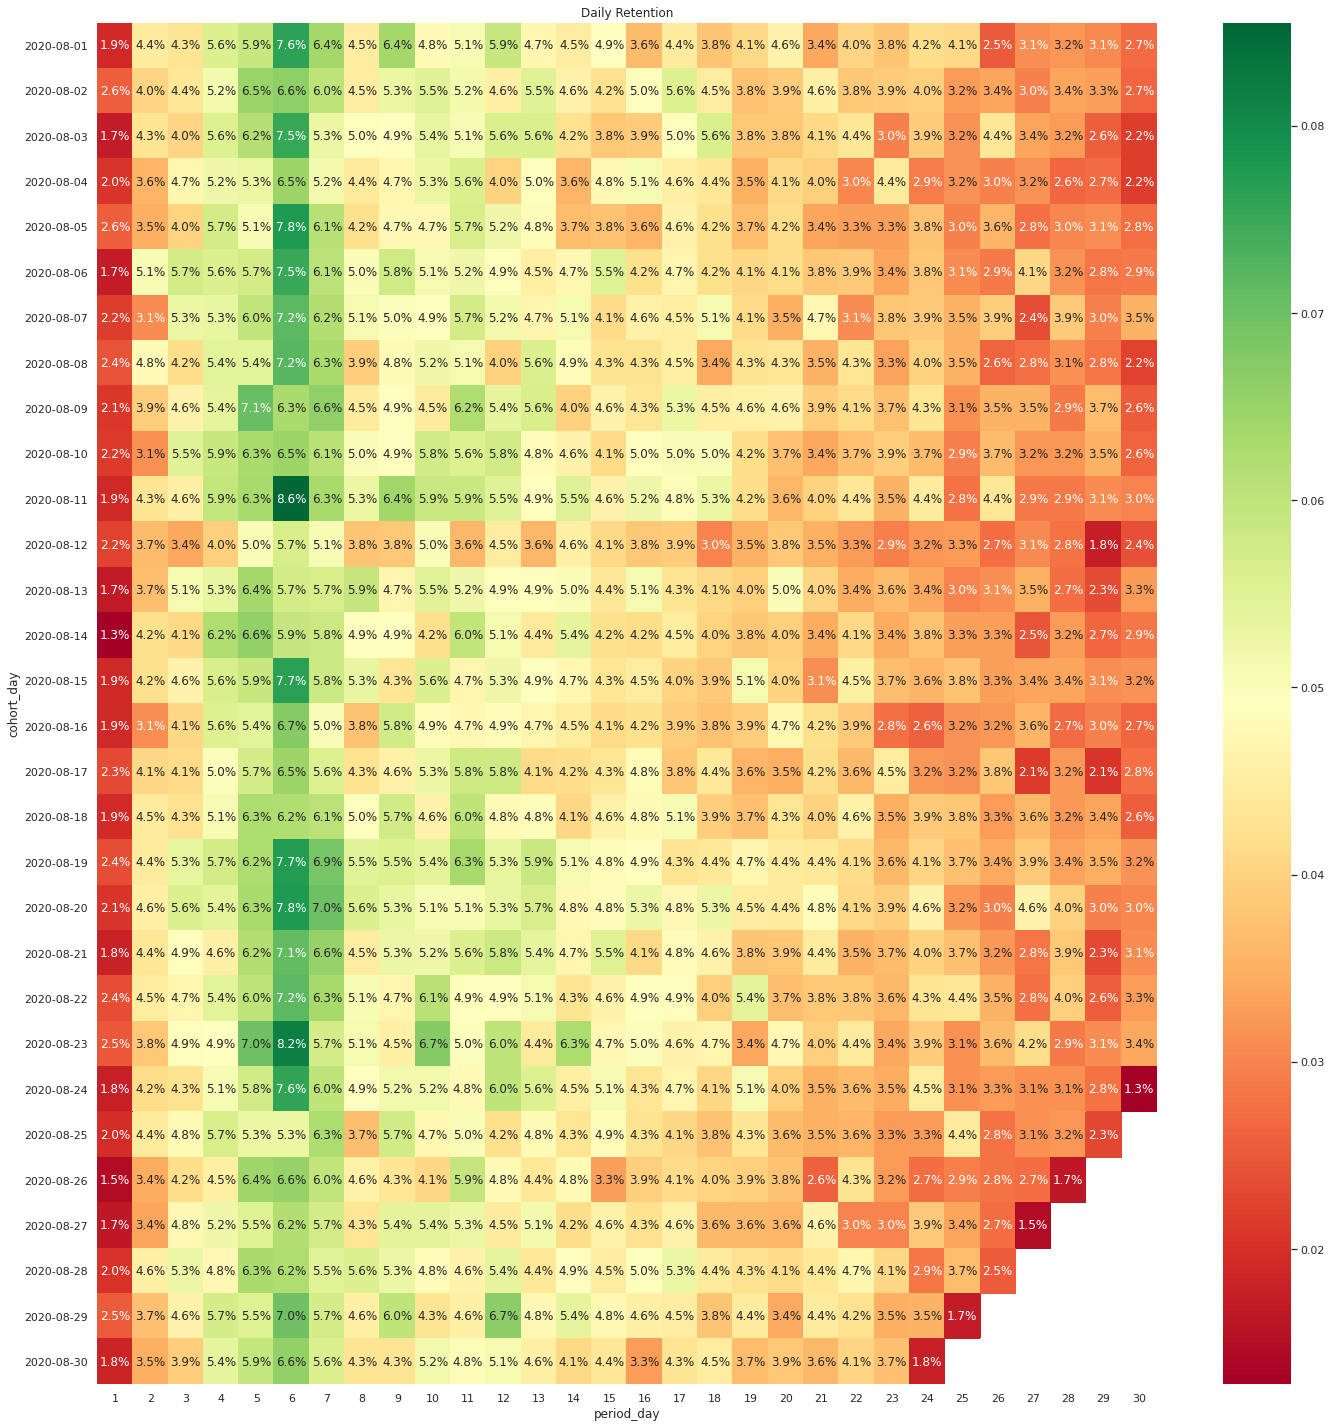

In [14]:
retention_matrix(reg, auth, '2020-08-01', '2020-08-31', heatmap=True)

### Задание 2

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [15]:
yandex_api = "https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={}"
public_url = "https://disk.yandex.ru/d/3_5cZN1m9cvknw"

response = requests.get(yandex_api.format(public_url), timeout=5)
response.raise_for_status()
download_url = response.json().get("href")

data = pd.read_csv(download_url, sep=';')

In [16]:
data = pd.read_csv(download_url, sep=';')
#data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

In [17]:
data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [18]:
data.shape

(404770, 3)

In [19]:
data.dtypes

user_id       int64
revenue       int64
testgroup    object
dtype: object

In [20]:
# Нет пропущенных значений
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


Большая часть пользователей не платящие, при этом среди тех кто платит разброс довольно большой, учитывая, что среднее примерно 26, а максимум равен 37433

In [21]:
data['revenue'].describe()

count    404770.000000
mean         26.083435
std         681.652928
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64

Выборки довольно сильно отличаются по разбросу значений, стандартное отклонение и максимум в контрольной выборке сильно выше, чем в тестовой выборке

In [22]:
print(data[data['testgroup']=='a']['revenue'].describe(), '\n') 
print(data[data['testgroup']=='b']['revenue'].describe())

count    202103.000000
mean         25.413720
std         920.768137
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64 

count    202667.000000
mean         26.751287
std         287.324162
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4000.000000
Name: revenue, dtype: float64


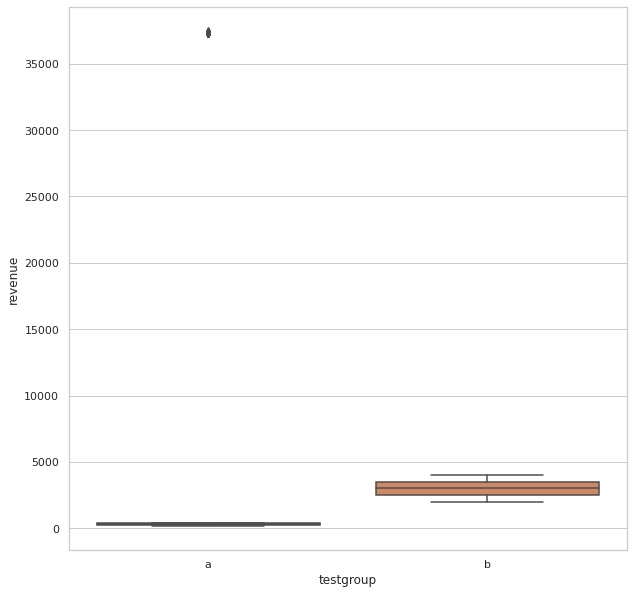

In [23]:
# Строю график по выручке в разрезе групп - очевидно, выборки довольно сильно отличаются
plt.figure(figsize=(10, 10))
sns.boxplot(data=data[data['revenue']>0], x='testgroup', y='revenue')
plt.show()

In [24]:
# 123 значения больше 37000 и все в контрольной выборке, что очень странно - может быть, ошибка в данных или просто какая-то особая подгруппа
data[data['revenue']>35000]

,user_id,revenue,testgroup
416,417,37324,a
4428,4429,37304,a
5777,5778,37315,a
8065,8066,37307,a
8743,8744,37334,a
...,...,...,...
360696,360697,37347,a
378668,378669,37297,a
389341,389342,37298,a
394580,394581,37302,a


Можно посчитать conversion rate, ARPU, ARPPU и сравнить контрольную (A) и тестовую (B) группы

Стоит отметить, что в контрольной выборке выше conversion rate, однако ARPU и ARPPU выше уже в тестовой выборке. Выборки выглядят не очень сбалансированными - стандартное отклонение очень сильно отличается в группах, плюс в контрольной группе есть значительные выбросы (123 значения в районе 37000 - очень странно), что также смещает выборку. Так совпало, что выбросов в контрольной группе почему-то ровно 123 и если их вычесть, то в обеих выборках получится равное количество платящих пользователей, поэтому я проверю метрики и тесты не только на начальных данных, но и на данных без этих 123 выбросов.

Разница ARPU в 5% может быть вызвана как раз несбалансированностью выборок, а не качественными отличиями акционного предложения в тестовой группе по сравнению с контрольной. Нужно провести тесты, чтобы сказать точнее, насколько достоверны результаты этого A/B эксперимента.

#### Изначальные данные

In [25]:
metrics = data.groupby('testgroup').agg(
    Users=('user_id', 'count'),
    Paying_users=('revenue', lambda x: (x > 0).sum()),
    Revenue=('revenue', 'sum')
).reset_index()

metrics['CR'] = metrics['Paying_users'] / metrics['Users']
metrics['ARPU'] = metrics['Revenue'] / metrics['Users']
metrics['ARPPU'] = metrics['Revenue'] / metrics['Paying_users']

metrics

,testgroup,Users,Paying_users,Revenue,CR,ARPU,ARPPU
0,a,202103,1928,5136189,0.009540,25.413720,2663.998444
1,b,202667,1805,5421603,0.008906,26.751287,3003.658172


Для сравнения ARPU и ARPPU в контрольной и тестовой выборках буду использовать t-test, так как имеем дело с количественными непрерывными данными и размер выборок достаточно большой (согласно ЦПТ, при достаточном размере выборок распределение средних будет приблизижено к нормальному).

Гипотезы для t-test для ARPU:

- Нулевая гипотеза (H0): Между тестовой и контрольной выборками нет разницы в ARPU. 

- Альтернативная гипотеза (H1): ARPU контрольной и тестовой выборок отличаются

In [26]:
a = data[data['testgroup'] == 'a']['revenue']
b = data[data['testgroup'] == 'b']['revenue']

t_stat, p_val = ttest_ind(a, b, equal_var=False)
print(f"T-test for ARPU: t = {t_stat}, p = {p_val}")

T-test for ARPU: t = -0.6234876562792212, p = 0.5329647014130866


p-value > 0.05, поэтому не отвергаем нулевую гипотезу - оснований говорить о разнице между выборками нет 

Для ARPPU аналогичные гипотезы

In [27]:
a = data[(data['testgroup'] == 'a') & (data['revenue']>0)]['revenue']
b = data[(data['testgroup'] == 'b') & (data['revenue']>0)]['revenue']

t_stat, p_val = ttest_ind(a, b, equal_var=False)
print(f"T-test for ARPPU: t = {t_stat}, p = {p_val}")

T-test for ARPPU: t = -1.6446302664300838, p = 0.10020780398916015


p-value > 0.05, поэтому не отвергаем нулевую гипотезу - оснований говорить о разнице между выборками нет

Для сравнения выборок по conversion rate можно использовать Z-тест, который используется для сравнения долей и хорош на больших выборках (наш случай)

In [28]:
x = [metrics['Paying_users'][0], metrics['Paying_users'][1]]
n = [metrics['Users'][0], metrics['Users'][1]]

z_stat, p_val = proportions_ztest(count=x, nobs=n)

print(f"Z-test for CR: z = {z_stat}, p = {p_val}")

Z-test for CR: z = 2.108028495889841, p = 0.035028524642854865


Так как p-value < 0.05, Z-тест говорит о значимой разнице между выборками с точки зрения conversion rate в пользу контрольной выборки, что, наверное, не очень хорошо (так как в A/B эксперименте хочется сравнивать похожие выборки) и опять заставляет усомниться в корректности данных и проведенного A/B теста.

Разницы с точки зрения ARPU или ARPPU тесты не обнаружили, а конверсия в контрольной выборке даже лучше. Однако, наблюдения в тестовой выборке более однородны и были бы более надежны при масштабировании акции. 

#### В контрольной выборке убрали 123 выброса

In [29]:
data2 = data[data['revenue']<37000]

После удаления выбросов разница между ARPU и ARPPU стала просто огромной. Из-за этих выбросов контрольная выборка имела огромное смещение и t-test не позволял найти значимые различия между выборками, хотя по графику boxplot видно, что выборки очень сильно отличаются.

In [30]:
metrics2 = data2.groupby('testgroup').agg(
    Users=('user_id', 'count'),
    Paying_users=('revenue', lambda x: (x > 0).sum()),
    Revenue=('revenue', 'sum')
).reset_index()

metrics2['CR'] = metrics2['Paying_users'] / metrics2['Users']
metrics2['ARPU'] = metrics2['Revenue'] / metrics2['Users']
metrics2['ARPPU'] = metrics2['Revenue'] / metrics2['Paying_users']

metrics2

,testgroup,Users,Paying_users,Revenue,CR,ARPU,ARPPU
0,a,201980,1805,545937,0.008937,2.702926,302.458172
1,b,202667,1805,5421603,0.008906,26.751287,3003.658172


In [31]:
# t-test для ARPU
a = data2[data2['testgroup'] == 'a']['revenue']
b = data2[data2['testgroup'] == 'b']['revenue']

t_stat, p_val = ttest_ind(a, b, equal_var=False)
print(f"T-test for ARPU: t = {t_stat}, p = {p_val}")

T-test for ARPU: t = -37.48854905417036, p = 1.529802212310516e-306


p-value < 0.05, поэтому отвергаем нулевую гипотезу - есть основания говорить о разнице между выборками

In [32]:
# t-test для ARPPU
a = data2[(data2['testgroup'] == 'a') & (data2['revenue']>0)]['revenue']
b = data2[(data2['testgroup'] == 'b') & (data2['revenue']>0)]['revenue']

t_stat, p_val = ttest_ind(a, b, equal_var=False)
print(f"T-test for ARPPU: t = {t_stat}, p = {p_val}")

T-test for ARPPU: t = -199.39722533995328, p = 0.0


p-value < 0.05, поэтому отвергаем нулевую гипотезу - есть основания говорить о разнице между выборками

In [33]:
x = [metrics2['Paying_users'][0], metrics2['Paying_users'][1]]
n = [metrics2['Users'][0], metrics2['Users'][1]]

z_stat, p_val = proportions_ztest(count=x, nobs=n)

print(f"Z-test for CR: z = {z_stat}, p = {p_val}")

Z-test for CR: z = 0.1024661880905615, p = 0.9183866495500822


p-value > 0.05, поэтому оснований говорить о разнице между выборками нет

Если рассматривать контрольную выборку без 123 указанных наблюдений в сравнении с тестовой выборкой, то становится очевидно преимущество предложений в тестовой выборке.

**Вывод**: Я считаю, что, в первую очередь, нужно прояснить природу 123 наблюдений со значениями в районе 37300 в контрольной выборке. Необходимо узнать у тех, кто проводил эксперимент, его подробности, что за акции предлагались клиентам и как собирались данные о его результатах. Есть вероятность, что эти 123 наблюдения с почти одинаковыми показателями revenue являются частью акционных предложений. Но тогда непонятно, относятся ли оставшиеся в контрольной группе 1805 ненулевых значений к этому же типу акционных предложений, потому что A/B-тест, как мне кажется, должен дизайниться таким образом, чтобы в одну выборку попадали акционные предложения одного типа. В нашем же случае в контрольной выборке мы имеем 2 очень отличающихся группы данных. То есть, существует вероятность того, что это ошибка сбора данных или ошибка в системе, из-за которой в контрольную группу попали 2 не связанные ационные кампании, например. Таким образом, на данном этапе нельзя делать однозначные выводы и требуется дополнительный анализ.  

### Задание 3

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

*Ответ на комментарий*: Я предполагаю, что мы смотрим на метрики в совокупности и не делаем поспешных выводов по изменениям одной метрики. Я постарался выделить максимальное количество метрик, которые могут помочь адекватно оценить результаты ивента. В зависимости от деталей конкретного ивента, норм внутри компании и т.д. что-то можно убирать или добавлять. В целом, можно было бы выделить по одной ключевой метрике в рамках каждого раздела.

1.) Самое базовое, с чего можно начать оценку события, это количество игроков, принявших в нем **участие**:

- Количество уникальных игроков, принявших участие в конкретном событии

- Доля игроков, которые начинали ивент, от общего числа активных игроков

- DAU (Daily Active Users) - общее количество игроков, игравших в игру за день (заходит ли больше людей в игру специально для этого ивента)

2.) Так как ивент предполагает прохождение нескольких уровней, нам было бы интересно отследить **прогресс игроков**:

- Среднее и медианное количество пройденных уровней

- Доля игроков, прошедших все уровни, от общего числа игроков, принявших участие в ивенте

- Доля игроков, принявших участие в ивенте и не прошедших ни одного уровня

- Распределение игроков по количеству пройденных уровней в целом

- Среднее и медианное время прохождения всего ивента и каждого отдельного уровня (также можно использовать для анализа сложности)

- Среднее и медианное количество попыток для прохождения каждого уровня (также можно использовать для анализа сложности)

3.) Чтобы понять, насколько успешным было событие, нужно проанализировать **удержание и вовлечённость**:

- Retention (удержание) игроков на следующий день, через 3/7 дней (в зависимости от продолжительности ивента)

- Частота заходов в игру во время события

4.) Такие ивенты должны поднимать активность игроков и стимулировать их больше играть и больше донатить, поэтому нас интересует **монетизация** ивента:

- Выручка от ивента

- Конверсия в покупку призов/предметов/дополнительных попыток

- Средний доход с пользователя (ARPU) среди игроков, принявших участие в ивенте

- Средний доход с платящего пользователя (ARPPU) среди игроков, принявших участие в ивенте

5.) Нам нужна **обратная связь** от игроков, чтобы улучшать ивента в будущем:

- Customer Satisfaction Index (CSI) - средняя удовлетворенность пользователей ивентом 

- Количество комментариев/лайков под постами о событии


Если при каждой неудачной попытке игрока откидывает назад на несколько уровней, то это, очевидно, поднимает сложность прохождения ивента, а также повысит раздражительность от игры. Мне кажется, что представленные выше метрики уже довольно неплохо позволят оценить такой ивент, однако приведу и несколько новых метрик, которые можно добавить специально под такой ивент. Выделю ключевые метрики для этого ивента, которые можно будет сравнить с метриками стандартного события:

- Распределение игроков по количеству пройденных уровней

- Среднее и медианное время прохождения всего ивента и каждого отдельного уровня

- Среднее и медианное количество попыток для прохождения каждого уровня

- Retention (удержание) игроков на следующий день, через 3/7 дней (в зависимости от продолжительности ивента)

- Средний доход с пользователя (ARPU) среди игроков, принявших участие в ивенте

- Средний доход с платящего пользователя (ARPPU) среди игроков, принявших участие в ивенте

Я бы добавил в анализ следующие метрики для анализа уровня терпения игроков и возможной корректировки количество уровней, на которое игроков отбрасывает назад, в будущем:

- Среднее и медианное количество возвратов

- Среднее и медианное количество возвратов, после которого игрок бросает прохождение

- Доля игроков, прекративших участие после первого отката